DOMINANT RESIDENTIAL BUILDING TYPE INSIDE NHDA - DISTRICT LEVEL
Loading VG250 districts ...
  96 districts (Bavaria) | CRS: EPSG:25832
lk_type
Landkreis           71
Kreisfreie Stadt    25

Loading NHDA polygons ...
  839 NHDA polygons

Loading buildings (bbox-filtered, res_subclass only) ...
  1,811,517 buildings | CRS: EPSG:25832
  Residential with res_subclass: 227,336

Computing building centroids ...
Assigning buildings to districts ...
  Fallback nearest-district for 1 centroids ...
Checking which buildings are inside NHDA (centroid-based) ...
  Buildings inside NHDA: 20,084 / 227,336

Buildings inside NHDA: 20,084
  Dominant type computed for 88 districts
lk_ags dominant_type  total_buildings
 09375        SFH-DB           1029.0
 09279        SFH-DB            782.0
 09275        SFH-DB            745.0
 09274        SFH-DB            710.0
 09278        SFH-DB            700.0
 09571        SFH-DB            655.0
 09373        SFH-DB            604.0
 09779        SFH-DB     

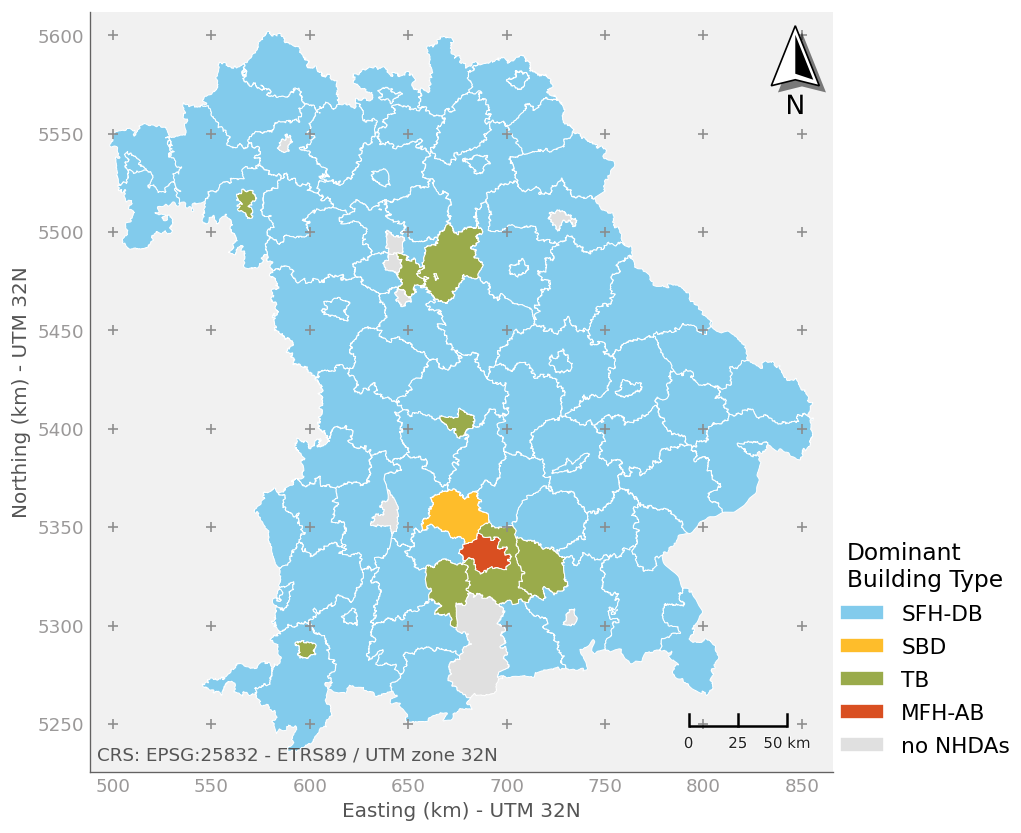


CSV saved: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda\landkreis_nhda_buildingtype_stats.csv
Done. Output: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda


In [27]:
"""
Dominant Residential Building Type inside NHDA at District Level in Bavaria
+ Percentage shares per building type per district

IMPORTANT:
- The expensive building assignment is cached.
- For plot adjustments, load cache only without recomputation.
"""

import math
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
LOD2_NEW = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\LoD2\LoD2_2025_new_buildings.gpkg"
NHDA_PATH = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\New_Housing_Development_Areas\NHDA_residential_wsf2015_max10pct.gpkg"
VG250_PATH = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Input\Verwaltungsgebiete\vg250-ew_12-31.utm32s.gpkg.ebenen\vg250-ew_ebenen_1231\DE_VG250.gpkg"
VG250_LAYER = "vg250_krs"

try:
    from matplotlib_map_utils import north_arrow, scale_bar
    HAS_MMU = True
except Exception:
    HAS_MMU = False

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 19,
    'axes.labelsize': 13,
    'legend.fontsize': 13,
    'legend.title_fontsize': 14,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
})

# ============================================================================
# CONFIGURATION
# ============================================================================

COL_GEOMETRY = 'geometry'
COL_RES_SUBCLASS = 'res_subclass'
COL_LK_KEY = 'LK_KEY'
COL_LK_NAME = 'LK_NAME'

BUILDING_TYPES = ['SFH-DB', 'SBD', 'TB', 'MFH-AB', 'unclassified res']

MAKE_MAP = True

COLOR_MAP_TYPES = {
    'SFH-DB': "#82cbec",
    'SBD': "#febd2b",
    'TB': "#9aab4b",
    'MFH-AB': "#d94f21",
    'unclassified res': "#b3b3b3",
}

TARGET_CRS = 'EPSG:25832'
CRS_NOTE = 'CRS: EPSG:25832 - ETRS89 / UTM zone 32N'
GRID_STEP_M = 50000
MAP_PADDING_M = 10000
LABEL_CLAMP_MARGIN_M = 7000

OUTPUT_DIR = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda")

# ============================================================================
# FUNCTIONS
# ============================================================================

def add_matplotlib_grid(ax, bounds, step=GRID_STEP_M):
    minx, miny, maxx, maxy = bounds
    x_start = math.ceil(minx / step) * step
    x_end = math.floor(maxx / step) * step
    y_start = math.ceil(miny / step) * step
    y_end = math.floor(maxy / step) * step

    x_major = [x_start + i * step for i in range(int((x_end - x_start) / step) + 1)] if x_start <= x_end else []
    y_major = [y_start + i * step for i in range(int((y_end - y_start) / step) + 1)] if y_start <= y_end else []

    ax.set_xticks(x_major)
    ax.set_yticks(y_major)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(round(x / 1000))}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{int(round(y / 1000))}'))

    if x_major and y_major:
        x_pts, y_pts = [], []
        for xv in x_major:
            for yv in y_major:
                x_pts.append(xv)
                y_pts.append(yv)
        ax.scatter(x_pts, y_pts, marker='+', s=30, linewidths=1.0, color='#8a8a8a', alpha=0.95, zorder=4, clip_on=True)

    ax.tick_params(axis='both', which='major', labelsize=11, length=0, colors='#9B9999')


def add_scientific_frame(ax, gdf_base):
    ax.set_facecolor('#f1f1f1')
    minx, miny, maxx, maxy = gdf_base.total_bounds
    bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M, maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.margins(0)
    add_matplotlib_grid(ax, bounds)
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.set_autoscale_on(False)
    ax.set_xlabel('Easting (km) - UTM 32N', fontsize=12, color='#555555')
    ax.set_ylabel('Northing (km) - UTM 32N', fontsize=12, color='#555555')
    ax.text(0.01, 0.01, CRS_NOTE, transform=ax.transAxes, ha='left', va='bottom', fontsize=11, color='#555555')
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('#636262')
        ax.spines[side].set_linewidth(0.8)


def add_north_arrow(ax):
    if HAS_MMU:
        north_arrow(ax=ax, location='upper right', size='md', rotation={'degrees': 0},
                    aob={'bbox_to_anchor': (0.985, 0.985), 'bbox_transform': ax.transAxes,
                         'pad': 0.06, 'borderpad': 0.06, 'facecolor': 'none',
                         'edgecolor': 'none', 'alpha': 1.0, 'frameon': False})
        return
    ax.annotate('N', xy=(0.965, 0.97), xytext=(0.965, 0.86),
                xycoords='axes fraction', textcoords='axes fraction',
                ha='center', va='center', fontsize=16, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', color='#222222', linewidth=1.4, shrinkA=0, shrinkB=0))


def add_scale_bar(ax):
    if HAS_MMU:
        scale_bar(ax=ax, location='lower right', size='xs', style='ticks',
                  bar={'projection': TARGET_CRS, 'unit': 'km', 'max': 50,
                       'major_div': 2, 'minor_div': 1, 'minor_type': 'none', 'reverse': False},
                  labels={'labels': ['0', '25', '50'], 'style': 'major', 'loc': 'below', 'fontsize': 9},
                  units={'loc': 'text', 'label': 'km'},
                  text={'fontfamily': 'sans-serif', 'fontsize': 9, 'textcolor': '#222222'},
                  aob={'pad': 0.0, 'borderpad': 1.0, 'facecolor': 'none',
                       'edgecolor': 'none', 'alpha': 1.0, 'frameon': False})
        return
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    span_x, span_y = x1 - x0, y1 - y0
    bar_len, segment_len = 50_000, 25_000
    x_start = x1 - span_x * 0.25
    y_start = y0 + span_y * 0.032
    ax.plot([x_start, x_start + bar_len], [y_start, y_start], color='#222222', linewidth=1.3, zorder=5)
    tick_h = span_y * 0.006
    for x in [x_start, x_start + segment_len, x_start + bar_len]:
        ax.plot([x, x], [y_start - tick_h, y_start + tick_h], color='#222222', linewidth=1.0, zorder=5)
    txt_y = y_start + span_y * 0.011
    ax.text(x_start, txt_y, '0', ha='center', va='bottom', fontsize=9, color='#222222')
    ax.text(x_start + segment_len, txt_y, '25', ha='center', va='bottom', fontsize=9, color='#222222')
    ax.text(x_start + bar_len, txt_y, '50 km', ha='center', va='bottom', fontsize=9, color='#222222')


# def add_labels_non_sfh(ax, gdf):
#     """Label all non-SFH-DB districts (incl. 'no NHDA buildings') with crossing-free leader lines.

#     Strategy: split features into left/right half by x-position, sort each half top-to-bottom
#     by feature y, assign label slots in the same order → leader lines cannot cross within a side.
#     """
#     required_cols = {COL_LK_NAME, 'dominant_type', COL_GEOMETRY}
#     if not required_cols.issubset(set(gdf.columns)):
#         print("  Notice: Required columns for labels missing"); return

#     # Include ALL non-SFH-DB districts (also those with no NHDA buildings)
#     gdf_labels = gdf[gdf['dominant_type'] != 'SFH-DB'].copy().reset_index(drop=True)
#     if gdf_labels.empty:
#         print("  Notice: No non-SFH-DB districts for labeling"); return

#     bounds = gdf.total_bounds
#     minx, miny, maxx, maxy = bounds
#     center_x = (minx + maxx) / 2

#     frame_x0, frame_x1 = minx - MAP_PADDING_M, maxx + MAP_PADDING_M
#     frame_y0, frame_y1 = miny - MAP_PADDING_M, maxy + MAP_PADDING_M
#     lbl_x_left  = frame_x0 + LABEL_CLAMP_MARGIN_M
#     lbl_x_right = frame_x1 - LABEL_CLAMP_MARGIN_M
#     lbl_y0 = frame_y0 + LABEL_CLAMP_MARGIN_M
#     lbl_y1 = frame_y1 - LABEL_CLAMP_MARGIN_M
#     span_y = frame_y1 - frame_y0
#     MIN_GAP = span_y * 0.030

#     def _norm_name(name):
#         n = str(name).strip()
#         for prefix in ['Landkreis ', 'Lkr. ', 'Stadtkreis ', 'Kreisfreie Stadt ', 'Landeshauptstadt ', 'Stadt ']:
#             n = n.replace(prefix, '')
#         return n.split(',')[0].strip().lower()

#     type_by_idx = {}
#     grouped = {}
#     for idx, row in gdf_labels.iterrows():
#         grouped.setdefault(_norm_name(row[COL_LK_NAME]), []).append((idx, row.geometry.area))
#     for key, items in grouped.items():
#         if len(items) <= 1: continue
#         for i, (idx, _) in enumerate(sorted(items, key=lambda x: x[1])):
#             type_by_idx[idx] = 'stadt' if i == 0 else 'landkreis'

#     def _format_label(idx, row):
#         raw = str(row[COL_LK_NAME]).strip()
#         base = raw.split(',')[0].strip()
#         if idx in type_by_idx:
#             return f"Stadt {base}" if type_by_idx[idx] == 'stadt' else f"Lkr. {base}"
#         if 'landkreis' in raw.lower() or raw.lower().startswith('lkr.'):
#             return f"Lkr. {base}"
#         if 'stadt' in raw.lower() or 'landeshauptstadt' in raw.lower():
#             return f"Stadt {base}"
#         return base

#     rep_points = list(gdf_labels.representative_point())
#     items = [
#         (idx, row, p, _format_label(idx, row))
#         for (idx, row), p in zip(gdf_labels.iterrows(), rep_points)
#     ]

#     left_items  = sorted([it for it in items if it[2].x <= center_x], key=lambda it: it[2].y, reverse=True)
#     right_items = sorted([it for it in items if it[2].x >  center_x], key=lambda it: it[2].y, reverse=True)

#     def spread_ys(feat_ys):
#         ys = list(feat_ys)
#         for k in range(1, len(ys)):
#             if ys[k - 1] - ys[k] < MIN_GAP:
#                 ys[k] = ys[k - 1] - MIN_GAP
#         for k in range(len(ys)):
#             ys[k] = max(ys[k], lbl_y0)
#         for k in range(len(ys) - 2, -1, -1):
#             if ys[k] - ys[k + 1] < MIN_GAP:
#                 ys[k] = ys[k + 1] + MIN_GAP
#         for k in range(len(ys)):
#             ys[k] = min(ys[k], lbl_y1)
#         return ys

#     frame_height = frame_y1 - frame_y0

#     def _ty_to_frac(ty):
#         return (ty - frame_y0) / frame_height

#     def draw_group(group, side):
#         if not group: return
#         x_frac = 0.015 if side == 'left' else 0.985
#         ha     = 'left' if side == 'left' else 'right'
#         label_ys = spread_ys([it[2].y for it in group])
#         for (idx, row, p, label_text), ty in zip(group, label_ys):
#             ax.annotate(
#                 label_text,
#                 xy=(p.x, p.y),
#                 xycoords='data',
#                 xytext=(x_frac, _ty_to_frac(ty)),
#                 textcoords='axes fraction',
#                 ha=ha, va='center',
#                 fontsize=9,
#                 color='#1f1f1f',
#                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.70, pad=0.6),
#                 arrowprops=dict(arrowstyle='-', color='#8a8a8a', lw=0.6),
#                 zorder=6,
#             )

#     draw_group(left_items,  'left')
#     draw_group(right_items, 'right')


# def add_legend_bottom_right(ax, handles, title):
#     ax.legend(handles=handles, title=title, loc='lower left', bbox_to_anchor=(1.01, 0.02),
#               borderaxespad=0.0, frameon=False, fontsize=13, title_fontsize=14,
#               handlelength=2.0, labelspacing=0.6, borderpad=0.0)


def plot_dominant_type_map(gdf, output_dir):
    print("\nCreating map: Dominant building type inside NHDA (district level)...")
    fig, ax = plt.subplots(figsize=(8.6, 9.4))
    fig.subplots_adjust(right=0.80, left=0.08, top=0.92, bottom=0.10)

    color_map_ext = {**COLOR_MAP_TYPES, 'no NHDAs': '#e0e0e0'}
    colors = gdf['dominant_type'].map(color_map_ext).fillna('#e0e0e0')
    gdf.plot(ax=ax, color=colors, edgecolor='white', linewidth=0.6, zorder=2)

    present_types = [t for t in BUILDING_TYPES if t in gdf['dominant_type'].unique()]
    legend_elements = [mpatches.Patch(facecolor=COLOR_MAP_TYPES[t], edgecolor='white', label=t)
                       for t in present_types]
    if 'no NHDAs' in gdf['dominant_type'].unique():
        legend_elements.append(mpatches.Patch(facecolor='#e0e0e0', edgecolor='white', label='no NHDAs'))

    # add_labels_non_sfh(ax, gdf)
    # ax.set_title('Dominant Residential Building Type inside NHDA\nat District Level in Bavaria',
                #  fontweight='bold', fontsize=17, pad=14)
    add_scientific_frame(ax, gdf)
    add_north_arrow(ax)
    add_scale_bar(ax)
    add_legend_bottom_right(ax, legend_elements, 'Dominant\nBuilding Type')

    output_dir.mkdir(parents=True, exist_ok=True)
    out_file = output_dir / 'dominant_type_nhda_bayern_landkreise.jpg'
    plt.savefig(out_file, bbox_inches='tight', facecolor='white', format='jpg')
    print(f"  Saved: {out_file}")
    plt.show()
    plt.close()


# ============================================================================
# MAIN PROGRAM
# ============================================================================

print("=" * 72)
print("DOMINANT RESIDENTIAL BUILDING TYPE INSIDE NHDA - DISTRICT LEVEL")
print("=" * 72)

# 1. Load VG250 districts for Bavaria first (small file, needed for bbox filter)
print("Loading VG250 districts ...")
lkr_raw = gpd.read_file(VG250_PATH, layer=VG250_LAYER)
lkr_by = lkr_raw[lkr_raw["AGS"].astype(str).str.startswith("09")].to_crs(TARGET_CRS).copy()
print(f"  {len(lkr_by):,} districts (Bavaria) | CRS: {lkr_by.crs}")

# 2. Build district GeoDataFrame with type label
type_candidates = [c for c in lkr_by.columns if "bez" in c.lower() or "art" in c.lower()]
type_col = type_candidates[0] if type_candidates else None
lk_type_series = lkr_by[type_col].astype(str) if type_col else lkr_by["GEN"].astype(str)
lkr_by["lk_type"] = lk_type_series.apply(
    lambda x: "Landkreis" if ("landkreis" in x.lower() or "lkr" in x.lower()) else "Kreisfreie Stadt"
)
lkr = lkr_by[["AGS", "GEN", "lk_type", "geometry"]].rename(
    columns={"AGS": "lk_ags", "GEN": "lk_name"}
).copy()
print(lkr["lk_type"].value_counts().to_string())

# 3. Load NHDA polygons
print("\nLoading NHDA polygons ...")
gdf_nhda = gpd.read_file(NHDA_PATH).to_crs(TARGET_CRS)
print(f"  {len(gdf_nhda):,} NHDA polygons")

# 4. Load buildings – ONLY res_subclass column, filtered to Bavaria bbox
bavaria_bbox = tuple(lkr.total_bounds)
print(f"\nLoading buildings (bbox-filtered, res_subclass only) ...")
gdf_new = gpd.read_file(LOD2_NEW, bbox=bavaria_bbox, columns=["res_subclass"])
if gdf_new.crs.to_epsg() != 25832:
    gdf_new = gdf_new.to_crs(TARGET_CRS)
print(f"  {len(gdf_new):,} buildings | CRS: {gdf_new.crs}")

# 5. Filter to residential buildings with known subclass
gdf_res = gdf_new[gdf_new["res_subclass"].notna()].copy()
del gdf_new  # free memory
print(f"  Residential with res_subclass: {len(gdf_res):,}")

# Compute centroids once – used for BOTH district assignment and NHDA check.
# Using centroids consistently avoids cross-border mismatches where a building
# polygon straddles two districts/NHDA areas (e.g. Stadt vs. Landkreis Rosenheim).
print("\nComputing building centroids ...")
gdf_centroids = gdf_res[["geometry"]].copy()
gdf_centroids["geometry"] = gdf_centroids.geometry.centroid

# 6. Assign each building to a district via centroid sjoin
print("Assigning buildings to districts ...")
joined_lkr = gpd.sjoin(
    gdf_centroids,
    lkr[["lk_ags", "lk_name", "lk_type", "geometry"]],
    how="left",
    predicate="within",
)
# De-duplicate: building centroid on shared boundary can match two districts → keep first
joined_lkr = joined_lkr[~joined_lkr.index.duplicated(keep='first')]

# Fallback: nearest district for centroids that fall outside all polygons (e.g. border sliver)
missing_mask = joined_lkr["lk_ags"].isna()
if missing_mask.any():
    print(f"  Fallback nearest-district for {missing_mask.sum()} centroids ...")
    nearest = gpd.sjoin_nearest(
        gdf_centroids.loc[missing_mask],
        lkr[["lk_ags", "lk_name", "lk_type", "geometry"]],
        how="left",
    ).drop_duplicates(keep='first')
    joined_lkr.loc[missing_mask, "lk_ags"]  = nearest["lk_ags"]
    joined_lkr.loc[missing_mask, "lk_name"] = nearest["lk_name"]
    joined_lkr.loc[missing_mask, "lk_type"] = nearest["lk_type"]

gdf_res["lk_ags"]  = joined_lkr["lk_ags"].reindex(gdf_res.index).values
gdf_res["lk_name"] = joined_lkr["lk_name"].reindex(gdf_res.index).values
gdf_res["lk_type"] = joined_lkr["lk_type"].reindex(gdf_res.index).values

# 7. Flag buildings inside NHDA – also using centroids (same reference point as district
#    assignment) to prevent polygon-boundary artefacts.
print("Checking which buildings are inside NHDA (centroid-based) ...")
nhda_flag = gdf_nhda[["geometry"]].copy()
nhda_flag["_nhda"] = True

in_nhda_join = gpd.sjoin(
    gdf_centroids,
    nhda_flag,
    how="left",
    predicate="within",
)
# A centroid inside multiple NHDA polygons → collapse to single True flag
in_nhda_flag = in_nhda_join["_nhda"].notna().groupby(level=0).any()
gdf_res["in_nhda"] = in_nhda_flag.reindex(gdf_res.index, fill_value=False).values

del gdf_centroids, joined_lkr, in_nhda_join, nhda_flag
print(f"  Buildings inside NHDA: {gdf_res['in_nhda'].sum():,} / {len(gdf_res):,}")

# 8. Summary: counts inside / outside NHDA per district
agg = (
    gdf_res.groupby(["lk_ags", "lk_name", "lk_type"])["in_nhda"]
    .agg(n_in_nhda=lambda x: x.sum(), n_outside_nhda=lambda x: (~x).sum(), n_total="count")
    .reset_index()
)

# 9. Compute dominant building type – only buildings inside NHDA
gdf_nhda_only = gdf_res[gdf_res["in_nhda"]].copy()
print(f"\nBuildings inside NHDA: {len(gdf_nhda_only):,}")

stats = gdf_nhda_only.groupby(["lk_ags", "res_subclass"]).size().reset_index(name='count')
stats_pivot = stats.pivot_table(
    index="lk_ags", columns="res_subclass", values="count", fill_value=0
).reset_index()
stats_pivot.columns.name = None
for t in BUILDING_TYPES:
    if t not in stats_pivot.columns:
        stats_pivot[t] = 0

type_cols = BUILDING_TYPES.copy()
stats_pivot['total_buildings'] = stats_pivot[type_cols].sum(axis=1)
for t in type_cols:
    stats_pivot[f'{t}_pct'] = (stats_pivot[t] / stats_pivot['total_buildings'] * 100).round(2)
stats_pivot['dominant_type'] = stats_pivot[type_cols].idxmax(axis=1)
stats_pivot['dominant_type_count'] = stats_pivot[type_cols].max(axis=1)
stats_pivot['dominant_type_pct'] = (stats_pivot['dominant_type_count'] / stats_pivot['total_buildings'] * 100).round(2)

print(f"  Dominant type computed for {len(stats_pivot)} districts")
print(stats_pivot[['lk_ags', 'dominant_type', 'total_buildings']]
      .sort_values('total_buildings', ascending=False).head(10).to_string(index=False))

# 10. Merge district geometry + stats -> gdf_result
lkr_plot = lkr.rename(columns={"lk_ags": COL_LK_KEY, "lk_name": COL_LK_NAME})
stats_lk = stats_pivot.rename(columns={"lk_ags": COL_LK_KEY})

gdf_result = lkr_plot.merge(stats_lk, on=COL_LK_KEY, how="left")
gdf_result['dominant_type'] = gdf_result['dominant_type'].fillna('no NHDAs')
gdf_result['total_buildings'] = gdf_result['total_buildings'].fillna(0).astype(int)

agg_renamed = agg.rename(columns={"lk_ags": COL_LK_KEY})
gdf_result = gdf_result.merge(
    agg_renamed[[COL_LK_KEY, "n_in_nhda", "n_outside_nhda", "n_total"]],
    on=COL_LK_KEY, how="left"
)
print(f"\ngdf_result: {len(gdf_result)} districts")
print("Dominant type distribution:")
print(gdf_result['dominant_type'].value_counts())

# 11. Map
if MAKE_MAP:
    plot_dominant_type_map(gdf_result, OUTPUT_DIR)

# 12. CSV export
csv_file = OUTPUT_DIR / 'landkreis_nhda_buildingtype_stats.csv'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

stats_export_cols = (['total_buildings', 'dominant_type', 'dominant_type_count', 'dominant_type_pct']
                     + BUILDING_TYPES + [f'{t}_pct' for t in BUILDING_TYPES])
available_cols = [c for c in stats_export_cols if c in gdf_result.columns]

export_df = gdf_result[[COL_LK_KEY]].copy()
export_df.insert(1, 'Name', gdf_result[COL_LK_NAME].values)
for col in available_cols:
    export_df[col] = gdf_result[col].values
for col in ["n_in_nhda", "n_outside_nhda", "n_total"]:
    if col in gdf_result.columns:
        export_df[col] = gdf_result[col].values

export_df = export_df.rename(columns={COL_LK_KEY: 'ARS'})
export_df['ARS'] = export_df['ARS'].astype(str).str.zfill(5)
export_df.to_csv(csv_file, index=False, encoding='utf-8-sig')
print(f"\nCSV saved: {csv_file}")
print(f"Done. Output: {OUTPUT_DIR}")


Excluded districts without NHDA: 8
District totals (should be 100): min=100.000000, max=100.000000

Median building-type ratios (%) per Regierungsbezirk:


,SFH-DB,SBD,TB,MFH-AB,unclassified res
regbez,,,,,
Oberbayern,48.18,17.49,12.13,9.57,0.0
Niederbayern,65.10,17.23,1.14,14.56,0.0
Oberpfalz,79.31,7.28,0.00,12.15,0.0
Oberfranken,82.61,2.17,0.00,10.13,0.0
Mittelfranken,65.38,5.78,21.85,10.32,0.0
Unterfranken,74.67,4.00,0.00,12.77,0.0
Schwaben,67.44,11.66,4.16,10.72,0.0


Saved median table: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda\median_building_type_ratios_by_regbez.csv
Saved: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda\nhda_res_ratio_all_regbez_horizontal.jpg


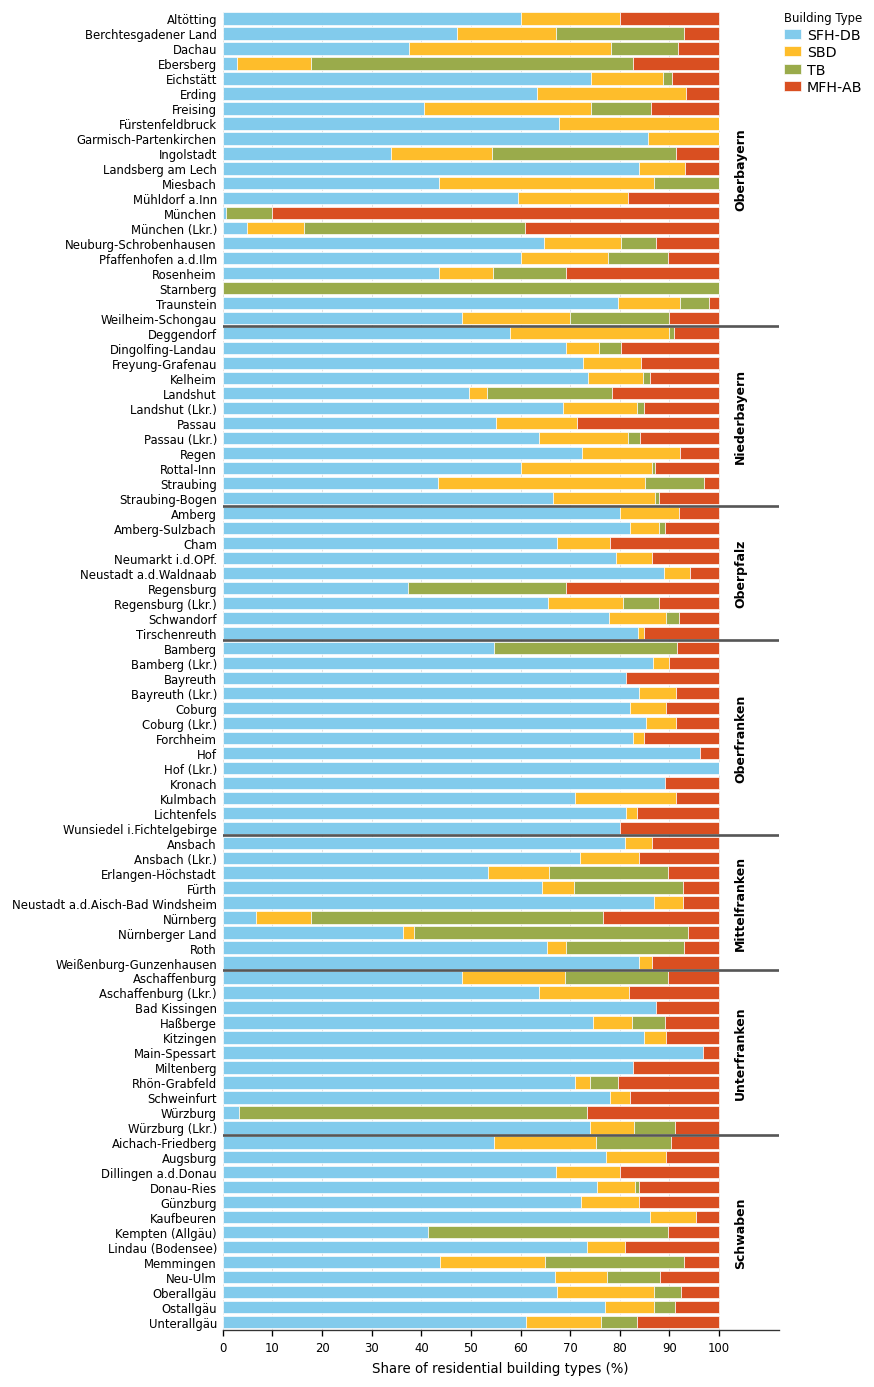

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# -----------------------------------------------------------------------------
# Horizontal stacked bars (one combined figure)
# - one bar per district, always summing to 100%
# - sorted by Regierungsbezirk
# - districts without NHDA are excluded from the chart
# - Landkreise labeled with (Lkr.) only if name is ambiguous
# - median building-type ratios are computed per Regierungsbezirk
# -----------------------------------------------------------------------------

EXPORT_DIR = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# --- 1) Input -----------------------------------------------------------------
if 'export_df' in globals():
    base_df = export_df.copy()
elif 'gdf_result' in globals():
    base_df = gdf_result.copy()
else:
    default_csv = EXPORT_DIR / 'landkreis_nhda_buildingtype_stats.csv'
    if default_csv.exists():
        base_df = pd.read_csv(default_csv)
    else:
        raise ValueError('No input table found. Run cell 1 first or provide landkreis_nhda_buildingtype_stats.csv.')

if 'ARS' not in base_df.columns and 'LK_KEY' in base_df.columns:
    base_df = base_df.rename(columns={'LK_KEY': 'ARS'})
if 'ARS' not in base_df.columns:
    raise ValueError('Missing ARS column (expected ARS or LK_KEY).')

if 'county' not in base_df.columns:
    if 'Name' in base_df.columns:
        base_df = base_df.rename(columns={'Name': 'county'})
    elif 'lk_name' in base_df.columns:
        base_df = base_df.rename(columns={'lk_name': 'county'})
    else:
        raise ValueError('Missing district name column (expected county/Name/lk_name).')

base_df['ARS'] = base_df['ARS'].astype(str).str.zfill(5)
base_df['county'] = base_df['county'].astype(str).str.strip()

if 'lk_type' in base_df.columns:
    district_meta = base_df[['ARS', 'county', 'lk_type']].drop_duplicates(subset=['ARS']).copy()
elif 'lkr' in globals() and {'lk_ags', 'lk_name', 'lk_type'}.issubset(set(lkr.columns)):
    district_meta = lkr[['lk_ags', 'lk_name', 'lk_type']].rename(columns={'lk_ags': 'ARS', 'lk_name': 'county'}).copy()
    district_meta['ARS'] = district_meta['ARS'].astype(str).str.zfill(5)
    district_meta['county'] = district_meta['county'].astype(str).str.strip()
else:
    district_meta = base_df[['ARS', 'county']].drop_duplicates(subset=['ARS']).copy()
    district_meta['lk_type'] = pd.NA

# --- 2) Build share table ------------------------------------------------------
building_types = ['SFH-DB', 'SBD', 'TB', 'MFH-AB', 'unclassified res']

if {'building_type', 'share'}.issubset(base_df.columns):
    long_df = base_df[['ARS', 'county', 'building_type', 'share']].copy()
    long_df['building_type'] = long_df['building_type'].astype(str).str.strip()
    long_df['share'] = pd.to_numeric(long_df['share'], errors='coerce').fillna(0.0)
    long_df = long_df.groupby(['ARS', 'county', 'building_type'], as_index=False)['share'].mean()
    wide = long_df.pivot_table(
        index=['ARS', 'county'],
        columns='building_type',
        values='share',
        aggfunc='mean',
        fill_value=0
    ).reset_index()
else:
    pct_cols = [f'{bt}_pct' for bt in building_types if f'{bt}_pct' in base_df.columns]
    if not pct_cols:
        raise ValueError('No building-type shares found (expected *_pct columns or building_type/share).')
    wide = base_df[['ARS', 'county'] + pct_cols].drop_duplicates(subset=['ARS']).copy()
    wide = wide.rename(columns={f'{bt}_pct': bt for bt in building_types if f'{bt}_pct' in wide.columns})

for bt in building_types:
    if bt not in wide.columns:
        wide[bt] = 0.0
    wide[bt] = pd.to_numeric(wide[bt], errors='coerce').fillna(0.0)

wide['sum_share'] = wide[building_types].sum(axis=1)
has_nhda = wide['sum_share'] > 0
removed_no_nhda = int((~has_nhda).sum())
wide = wide.loc[has_nhda].copy()

if wide.empty:
    raise ValueError('After filtering, no districts with NHDA remain to plot.')

wide[building_types] = wide[building_types].div(wide['sum_share'], axis=0) * 100
plot_types = building_types

wide['sum_final'] = wide[plot_types].sum(axis=1)
wide['SFH-DB'] = wide['SFH-DB'] + (100.0 - wide['sum_final'])

check = wide[plot_types].sum(axis=1)
print(f'Excluded districts without NHDA: {removed_no_nhda}')
print(f'District totals (should be 100): min={check.min():.6f}, max={check.max():.6f}')

# --- 3) Sorting and labels -----------------------------------------------------
regbez_map = {
    '091': 'Oberbayern',
    '092': 'Niederbayern',
    '093': 'Oberpfalz',
    '094': 'Oberfranken',
    '095': 'Mittelfranken',
    '096': 'Unterfranken',
    '097': 'Schwaben',
}
regbez_order = ['Oberbayern', 'Niederbayern', 'Oberpfalz', 'Oberfranken', 'Mittelfranken', 'Unterfranken', 'Schwaben']

wide['regbez_code'] = wide['ARS'].str[:3]
wide['regbez'] = wide['regbez_code'].map(regbez_map)
wide = wide.dropna(subset=['regbez']).copy()

district_meta['ARS'] = district_meta['ARS'].astype(str).str.zfill(5)
wide = wide.merge(district_meta[['ARS', 'lk_type']].drop_duplicates(subset=['ARS']), on='ARS', how='left')

def _clean_name(name):
    n = str(name).strip()
    for p in ['Landkreis ', 'Lkr. ', 'Kreisfreie Stadt ', 'Stadt ', 'Landeshauptstadt ']:
        if n.lower().startswith(p.lower()):
            return n[len(p):].strip()
    return n

wide['base_name'] = wide['county'].apply(_clean_name)
ambiguous_names = set(wide['base_name'].value_counts()[lambda s: s > 1].index)

def _label(name, lk_type, name_is_ambiguous):
    n = _clean_name(name)
    t = '' if pd.isna(lk_type) else str(lk_type).strip().lower()
    if 'landkreis' in t and name_is_ambiguous:
        return f'{n} (Lkr.)'
    return n

wide['district_label'] = wide.apply(
    lambda r: _label(r['county'], r['lk_type'], r['base_name'] in ambiguous_names), axis=1
)
dup = wide['district_label'].duplicated(keep=False)
wide.loc[dup, 'district_label'] = wide.loc[dup, 'district_label'] + ' [' + wide.loc[dup, 'ARS'] + ']'

wide['regbez'] = pd.Categorical(wide['regbez'], categories=regbez_order, ordered=True)
wide = wide.sort_values(['regbez', 'district_label']).reset_index(drop=True)

# --- 3b) Median ratios per administrative region -------------------------------
median_by_regbez = (
    wide.groupby('regbez', observed=False)[plot_types]
    .median()
    .reindex(regbez_order)
    .dropna(how='all')
    .round(2)
)

print('\nMedian building-type ratios (%) per Regierungsbezirk:')
display(median_by_regbez)

median_out = EXPORT_DIR / 'median_building_type_ratios_by_regbez.csv'
median_by_regbez.to_csv(median_out, encoding='utf-8-sig')
print(f'Saved median table: {median_out}')

# --- 4) Horizontal plot --------------------------------------------------------
colors = {
    'SFH-DB': '#82cbec',
    'SBD': '#febd2b',
    'TB': '#9aab4b',
    'MFH-AB': '#d94f21',
    'unclassified res': '#b3b3b3',
}
plot_order = ['SFH-DB', 'SBD', 'TB', 'MFH-AB', 'unclassified res']

fig, ax = plt.subplots(figsize=(8.27, 11.69))

y = range(len(wide))
left = pd.Series(0.0, index=wide.index)
present_types = [t for t in plot_order if wide[t].sum() > 0]

for t in present_types:
    vals = wide[t]
    ax.barh(
        y, vals, left=left, height=0.82,
        color=colors.get(t, '#7f7f7f'), edgecolor='white', linewidth=0.4, label=t
    )
    left = left + vals

ax.set_xlim(0, 112)
ax.set_xlabel('Share of residential building types (%)', fontsize=8)
ax.set_ylabel('')
ax.set_xticks(range(0, 101, 10))
ax.tick_params(axis='x', labelsize=7)
ax.set_yticks(list(y))
ax.set_yticklabels(wide['district_label'], fontsize=7)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.35, linewidth=0.6)
ax.set_axisbelow(True)

ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.margins(y=0)
ax.set_ylim(len(wide) - 0.5, -0.5)

group_sizes = wide['regbez'].value_counts(sort=False).reindex(regbez_order).fillna(0).astype(int)
start = 0
for rb, size in group_sizes.items():
    if size == 0:
        continue
    end = start + size - 1
    center = (start + end) / 2
    ax.text(103.0, center, rb, va='center', ha='left', rotation=90, fontsize=7.5, fontweight='bold')
    if end < len(wide) - 1:
        ax.axhline(end + 0.5, color='#444444', linewidth=1.6, alpha=0.9)
    start = end + 1

ax.legend(
    title='Building Type',
    ncol=1,
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    frameon=False,
    fontsize=8.5,
    title_fontsize=7,
    borderaxespad=0.0,
    handlelength=1.2,
    labelspacing=0.25,
    borderpad=0.0,
    columnspacing=0.6,
    handletextpad=0.4,
    markerscale=0.8,
    prop={'size': 8.5}
)

fig.subplots_adjust(left=0.31, right=0.87, top=0.985, bottom=0.045)

out_file = EXPORT_DIR / 'nhda_res_ratio_all_regbez_horizontal.jpg'
plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out_file}')

plt.show()

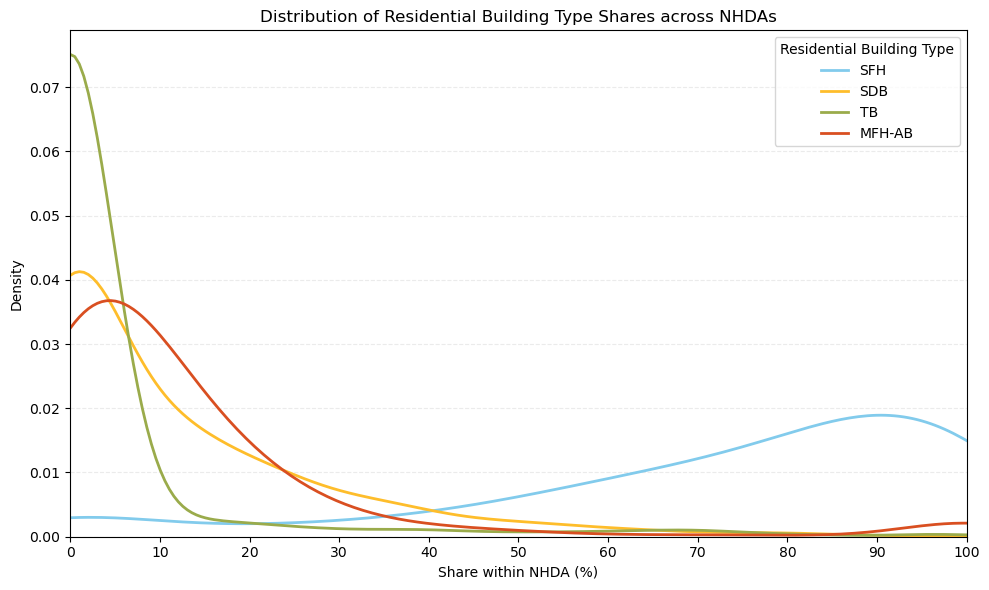

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path


fig, ax = plt.subplots(figsize=(10, 6))

gpkg_file = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Comparison_NHDA_RA\Comparison_LST_NDVI_DEGURB_CLC_BuildingStructure.gpkg"

# Load source data directly from the provided GPKG file.
df = gpd.read_file(gpkg_file)

# Keep NHDA rows if type information is available.
if "type" in df.columns:
    df = df[df["type"].astype(str).str.upper() == "NHDA"].copy()

types = {
    "SFH": "nhda_res_subclass_share_sfh_db",
    "SDB": "nhda_res_subclass_share_sbd",
    "TB": "nhda_res_subclass_share_tb",
    "MFH-AB": "nhda_res_subclass_share_mfh_ab",
}

color_map = {
    "SFH": "#82cbec",
    "SDB": "#febd2b",
    "TB": "#9aab4b",
    "MFH-AB": "#d94f21",
}

for label, col in types.items():
    if col not in df.columns:
        print(f"WARNING: Column not found: {col}")
        continue

    vals = pd.to_numeric(df[col], errors="coerce")

    # If shares are stored as 0..1, convert to 0..100 for plotting.
    if vals.dropna().max() <= 1.5:
        vals = vals * 100

    vals = vals.dropna()
    if vals.empty:
        continue

    sns.kdeplot(
        x=vals,
        bw_adjust=1.3,
        clip=(0, 100),
        color=color_map[label],
        linewidth=2,
        ax=ax,
        label=label,
    )

ax.set_xlabel("Share within NHDA (%)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Residential Building Type Shares across NHDAs")
ax.set_xlim(0, 100)
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(title="Residential Building Type")
ax.grid(axis="y", linestyle="--", alpha=0.25)
fig.tight_layout()
EXPORT_DIR = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda")
out_file = EXPORT_DIR / 'KDE_distribution_res_building_share.jpg'
plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()